In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# Apply the default theme
sns.set_theme()

In [ ]:
# data_url = "https://raw.githubusercontent.com/dthonon/pna_loup_suivi/main/data/"
data_url = Path(os.getcwd()).parents[-5] / "data"
# Lecture du fichier CSV
data = pd.read_csv(data_url / "aquila_2000.csv")

In [5]:
data["Temps"] = data["Pas"] / 3600
data.head()

,Pas,Contrôle,V0(V),V1(V),I(mA),E(mAh),Temps
0,0,0,0.001612,0.001612,0.0,0.0,0.000000
1,1,1,0.008061,0.008061,0.0,0.0,0.000278
2,2,1,0.008061,0.008061,0.0,0.0,0.000556
3,3,1,0.008061,0.008061,0.0,0.0,0.000833
4,4,1,0.008061,0.008061,0.0,0.0,0.001111


In [9]:
# Séparer data en 2 DataFrames selon la valeur de la colonne "Contrôle"
data_controle_0 = data[data["Contrôle"] == 0].copy()
data_controle_1 = data[data["Contrôle"] == 1].copy()

print("Contrôle = 0 :", data_controle_0.shape[0], "lignes")
print("Contrôle = 1 :", data_controle_1.shape[0], "lignes")

Contrôle = 0 : 116 lignes
Contrôle = 1 : 68379 lignes


In [ ]:
win_size = 61
data_controle_0["V_smooth"] = data_controle_0["V1(V)"].rolling(window=win_size, center=True).mean()
data_controle_0["I_smooth"] = data_controle_0["I(mA)"].rolling(window=win_size, center=True).mean()

data_controle_1["V_smooth"] = data_controle_1["V1(V)"].rolling(window=win_size, center=True).mean()
data_controle_1["I_smooth"] = data_controle_1["I(mA)"].rolling(window=win_size, center=True).mean()
data_controle_1["E_smooth"] = data_controle_1["E(mAh)"].rolling(window=win_size, center=True).mean()

,Pas,Contrôle,V0(V),V1(V),I(mA),E(mAh),Temps
0,0,0,0.001612,0.001612,0.000000,0.000000,0.000000
1,1,1,0.008061,0.008061,0.000000,0.000000,0.000278
2,2,1,0.008061,0.008061,0.000000,0.000000,0.000556
3,3,1,0.008061,0.008061,0.000000,0.000000,0.000833
4,4,1,0.008061,0.008061,0.000000,0.000000,0.001111
...,...,...,...,...,...,...,...
68490,54000,0,1.201026,1.201026,0.000000,1016.745112,15.000000
68491,54001,1,0.137030,0.972106,55.671715,1016.760576,15.000278
68492,54002,1,0.137030,0.955984,54.596971,1016.775742,15.000556
68493,54003,1,0.133806,0.962433,55.241817,1016.791087,15.000833


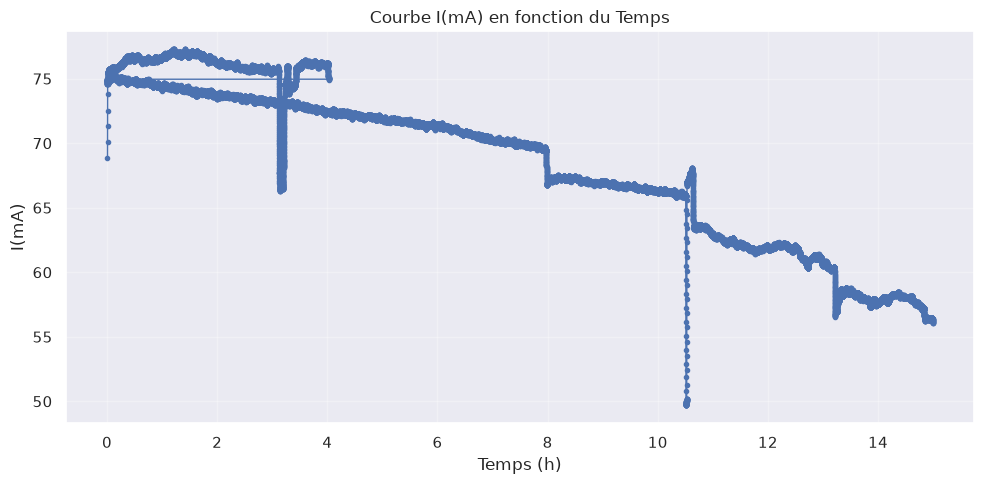

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_1["Temps"], data_controle_1["I_smooth"], marker=".", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("I(mA)")
plt.title("Courbe I(mA) en fonction du Temps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

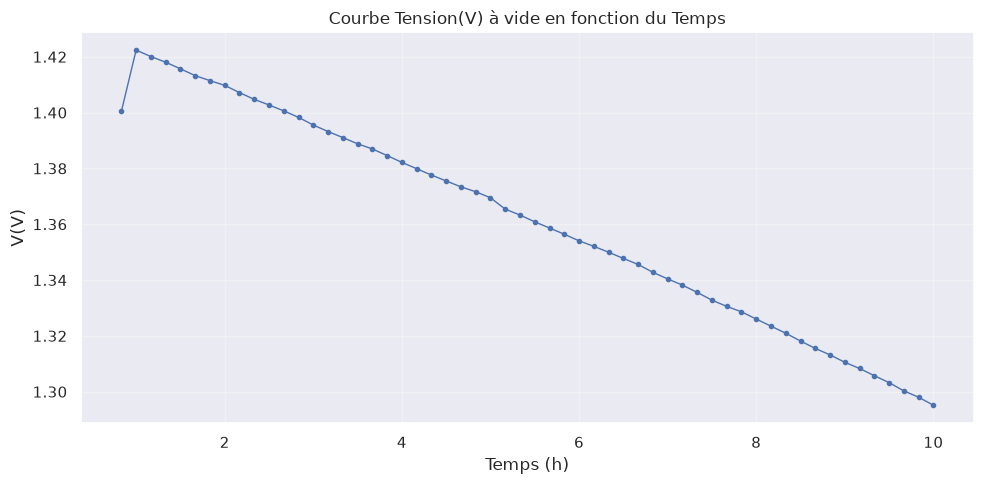

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_0["Temps"], data_controle_0["V_smooth"], marker=".", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("V(V)")
plt.title("Courbe Tension(V) à vide en fonction du Temps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

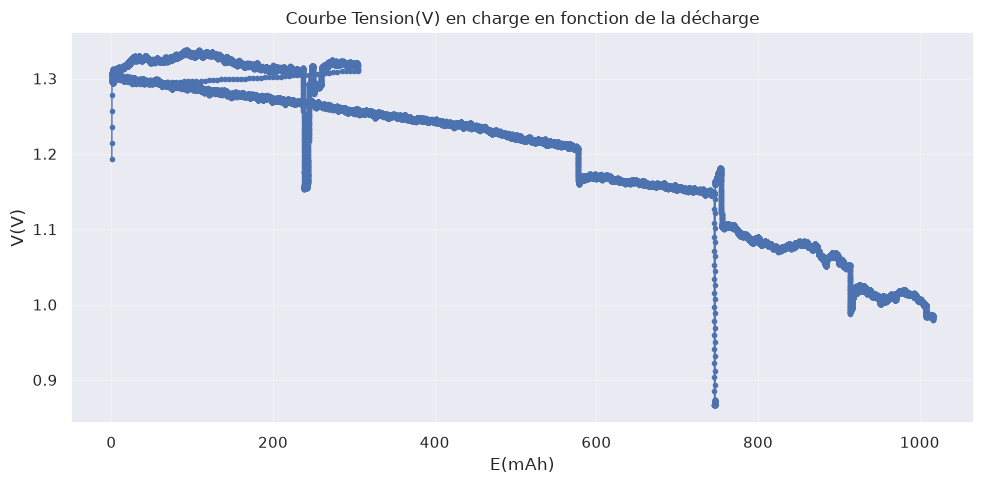

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_1["E_smooth"], data_controle_1["V_smooth"], marker=".", linewidth=1)
plt.xlabel("E(mAh)")
plt.ylabel("V(V)")
plt.title("Courbe Tension(V) en charge en fonction de la décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_1["Temps"], data_controle_1["V1(V)"], marker=".", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("V(V)")
plt.title("Courbe Tension(V) en charge en fonction de la décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()